# Car Price Prediction — AI & Big Data Final Project 2026
**Supervised Learning (Regression) · EDA → Training → Evaluation → Deployment**

This notebook covers **Step 1–3** of the project:
1. Data preparation & EDA
2. Training 2 supervised models (Linear Regression & Random Forest)
3. Model evaluation and selecting the best model for deployment

> **Dataset note.** This notebook uses `car_dataset.csv`, which has the **same column
> structure as the Kaggle "Car details v3" (CarDekho) dataset**
> (`name, year, selling_price, km_driven, fuel, seller_type, transmission, owner,
> mileage, engine, max_power, torque, seats`). To use the real Kaggle dataset for
> submission, download *Car details v3.csv* from Kaggle and load it instead — no code
> changes are needed because the columns match. Dataset has **>2000 rows and >12 columns**
> as required.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Data Preparation & EDA

### 1.1 Load the dataset

In [2]:
df = pd.read_csv("car_dataset.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (4235, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Honda WR-V,2010,50594,177403,CNG,Individual,Manual,First Owner,22.28 kmpl,1078 CC,58.6 bhp,70Nm@ 2500rpm,6.0
1,Honda City,2018,218600,80647,Diesel,Dealer,Automatic,Second Owner,20.48 kmpl,1521 CC,105.3 bhp,141Nm@ 1500rpm,7.0
2,Hyundai i10,2012,101720,135824,Petrol,Individual,Automatic,First Owner,19.35 kmpl,1529 CC,76.9 bhp,103Nm@ 1500rpm,6.0
3,Ford Figo,2016,148722,55684,Diesel,Dealer,Manual,First Owner,22.99 kmpl,1257 CC,72.2 bhp,127Nm@ 2000rpm,7.0
4,Mahindra Bolero,2014,124213,110563,Petrol,Individual,Manual,First Owner,15.62 kmpl,1962 CC,125.9 bhp,199Nm@ 4000rpm,7.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4235 entries, 0 to 4234
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4235 non-null   str    
 1   year           4235 non-null   int64  
 2   selling_price  4235 non-null   int64  
 3   km_driven      4235 non-null   int64  
 4   fuel           4235 non-null   str    
 5   seller_type    4235 non-null   str    
 6   transmission   4235 non-null   str    
 7   owner          4235 non-null   str    
 8   mileage        4185 non-null   str    
 9   engine         4185 non-null   str    
 10  max_power      4193 non-null   str    
 11  torque         4150 non-null   str    
 12  seats          4172 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 784.8 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4235,52,Hyundai Grand i10,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,4235.0,NaN,NaN,NaN,2014.41157,3.987926,2001.0,2012.0,2014.0,2017.0,2024.0
selling_price,4235.0,NaN,NaN,NaN,167315.415112,132266.017047,40000.0,85929.0,129482.0,200539.5,1340588.0
km_driven,4235.0,NaN,NaN,NaN,110239.454073,47557.896494,100.0,77028.5,110918.0,142307.0,289969.0
fuel,4235,4,Petrol,2284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,4235,3,Individual,3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4235,2,Manual,3238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,4235,5,First Owner,2648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,4185,1090,19.22 kmpl,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4185,1288,1605 CC,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Missing values

In [5]:
missing = df.isna().sum()
print(missing[missing > 0])
print("\nTotal missing cells:", df.isna().sum().sum())

mileage      50
engine       50
max_power    42
torque       85
seats        63
dtype: int64

Total missing cells: 290


### 1.3 Duplicate rows

In [6]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after :", df.duplicated().sum())
print("Shape after dedup    :", df.shape)

Duplicate rows before: 35
Duplicate rows after : 0
Shape after dedup    : (4200, 13)


### 1.4 Feature engineering
The columns `mileage`, `engine`, `max_power` are stored as text with units
(e.g. `"1248 CC"`). We strip the units to get numeric features, extract the car
**brand** from `name`, and compute **car_age**. Missing numeric values are filled
with the column median.

In [7]:
def to_num(s):
    if pd.isna(s):
        return np.nan
    return float(str(s).split()[0].replace("CC","").replace("bhp","").replace("kmpl","").strip())

df["mileage_kmpl"]  = df["mileage"].apply(to_num)
df["engine_cc"]     = df["engine"].apply(to_num)
df["max_power_bhp"] = df["max_power"].apply(to_num)
df["brand"]         = df["name"].str.split().str[0]
df["car_age"]       = 2024 - df["year"]

for c in ["mileage_kmpl", "engine_cc", "max_power_bhp", "seats"]:
    df[c] = df[c].fillna(df[c].median())

print("Missing after fill:", df[["mileage_kmpl","engine_cc","max_power_bhp","seats"]].isna().sum().sum())
df[["name","brand","car_age","mileage_kmpl","engine_cc","max_power_bhp","seats"]].head()

Missing after fill: 0


,name,brand,car_age,mileage_kmpl,engine_cc,max_power_bhp,seats
0,Honda WR-V,Honda,14,22.28,1078.0,58.6,6.0
1,Honda City,Honda,6,20.48,1521.0,105.3,7.0
2,Hyundai i10,Hyundai,12,19.35,1529.0,76.9,6.0
3,Ford Figo,Ford,8,22.99,1257.0,72.2,7.0
4,Mahindra Bolero,Mahindra,10,15.62,1962.0,125.9,7.0


### 1.5 Outlier detection & handling (IQR method)
We detect outliers on the target `selling_price` using the inter-quartile range
and remove rows outside `[Q1 - 1.5*IQR , Q3 + 1.5*IQR]`.

IQR bounds: [-85,296, 371,521]  ->  removed 289 rows, 3911 remain


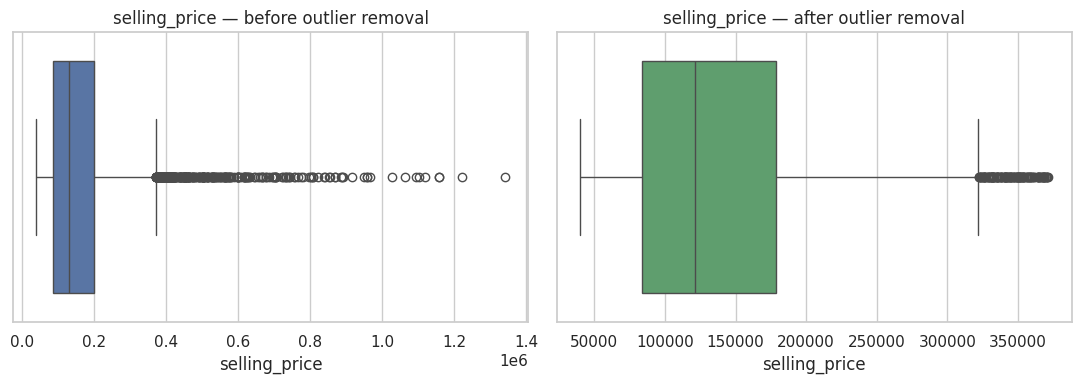

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df["selling_price"], ax=ax[0], color="#4C72B0")
ax[0].set_title("selling_price — before outlier removal")

q1, q3 = df["selling_price"].quantile([.25, .75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
before = len(df)
df = df[(df["selling_price"] >= lo) & (df["selling_price"] <= hi)].reset_index(drop=True)
print(f"IQR bounds: [{lo:,.0f}, {hi:,.0f}]  ->  removed {before-len(df)} rows, {len(df)} remain")

sns.boxplot(x=df["selling_price"], ax=ax[1], color="#55A868")
ax[1].set_title("selling_price — after outlier removal")
plt.tight_layout(); plt.show()

### 1.6 Visualizations

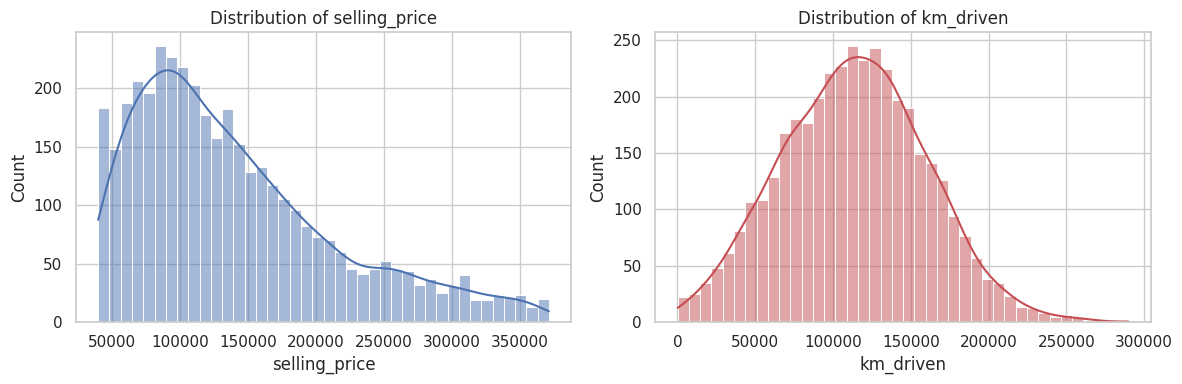

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["selling_price"], bins=40, kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribution of selling_price")
sns.histplot(df["km_driven"], bins=40, kde=True, ax=ax[1], color="#C44E52")
ax[1].set_title("Distribution of km_driven")
plt.tight_layout(); plt.show()

/tmp/ipykernel_754/3226568412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="brand", y="selling_price", order=order, palette="viridis")


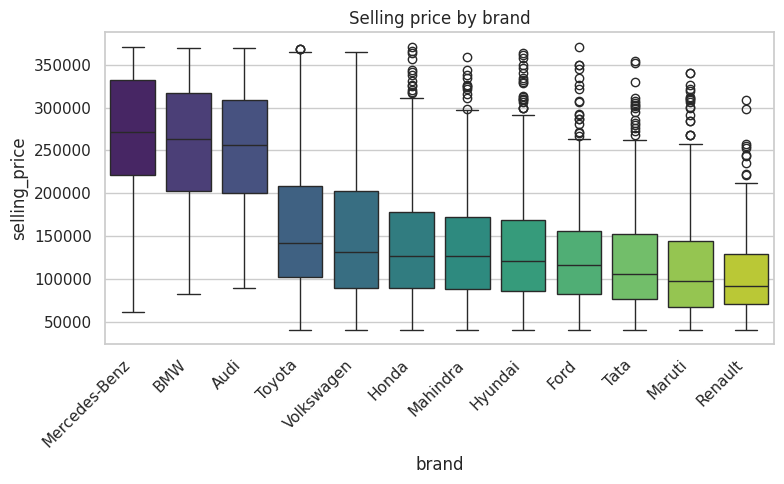

In [10]:
plt.figure(figsize=(8, 5))
order = df.groupby("brand")["selling_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="brand", y="selling_price", order=order, palette="viridis")
plt.xticks(rotation=45, ha="right"); plt.title("Selling price by brand"); plt.tight_layout(); plt.show()

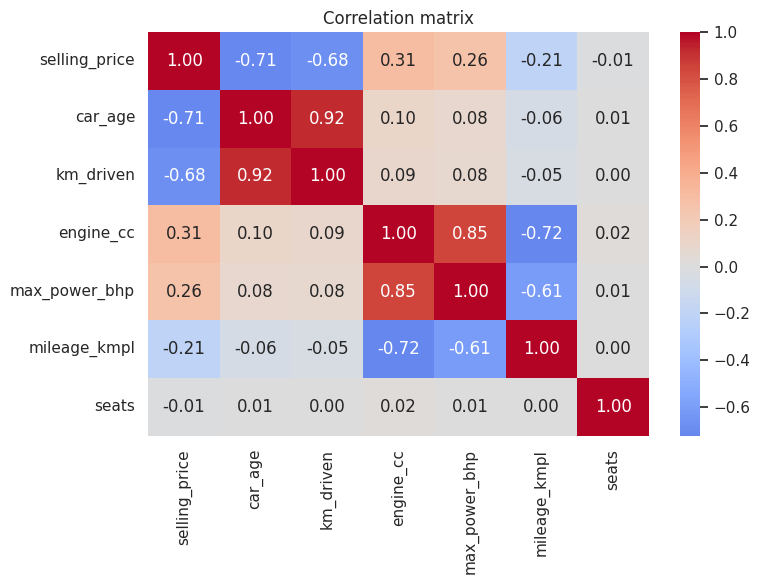

In [11]:
num_cols = ["selling_price","car_age","km_driven","engine_cc","max_power_bhp","mileage_kmpl","seats"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

## Step 2 — Training & Testing (2 Supervised Models)

We model `selling_price` (regression). All preprocessing (scaling numeric features,
one-hot encoding categoricals) is wrapped in a single scikit-learn **Pipeline** so the
exact same transforms are reused at deployment time. Split = **80% train / 20% test**.

In [12]:
num_feats = ["car_age", "km_driven", "engine_cc", "max_power_bhp", "mileage_kmpl", "seats"]
cat_feats = ["brand", "fuel", "seller_type", "transmission", "owner"]
features  = num_feats + cat_feats
target    = "selling_price"

X, y = df[features], df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])

Train: (3128, 11)  Test: (783, 11)


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=120, max_depth=14, random_state=42, n_jobs=-1),
}

fitted = {}
for name, est in models.items():
    pipe = Pipeline([("pre", preprocess), ("model", est)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"Trained: {name}")

Trained: Linear Regression


Trained: Random Forest


## Step 3 — Model Evaluation
Regression metrics: **MAE, MSE, RMSE, R²**.

In [14]:
rows = []
for name, pipe in fitted.items():
    pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    rows.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})

results = pd.DataFrame(rows).set_index("Model")
results_display = results.copy()
for c in ["MAE","MSE","RMSE"]:
    results_display[c] = results_display[c].map(lambda v: f"{v:,.0f}")
results_display["R2"] = results_display["R2"].map(lambda v: f"{v:.4f}")
results_display

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,"20,135","747,469,043","27,340",0.8812
Random Forest,"16,386","584,975,733","24,186",0.9070


In [15]:
best_name = results["R2"].idxmax()
best_pipe = fitted[best_name]
print("Best model (highest R2):", best_name)

Best model (highest R2): Random Forest


### 3.1 Predicted vs Actual (best model)

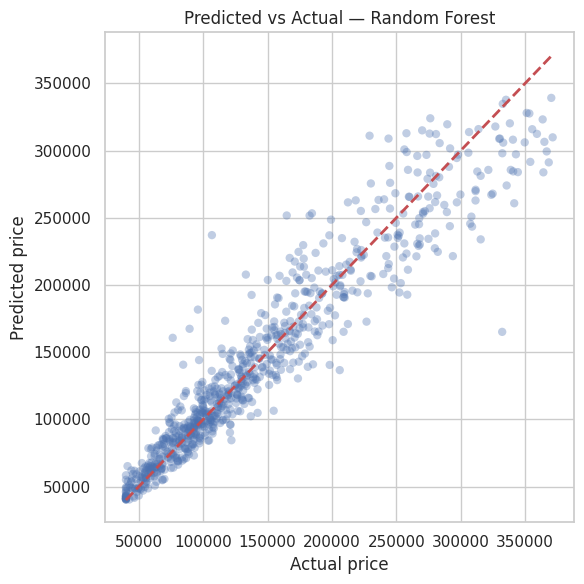

In [16]:
pred = best_pipe.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.35, edgecolor="none")
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("Actual price"); plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best_name}"); plt.tight_layout(); plt.show()

### 3.2 Feature importance (Random Forest)

/tmp/ipykernel_754/893643127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values, y=fi.index, palette="rocket")


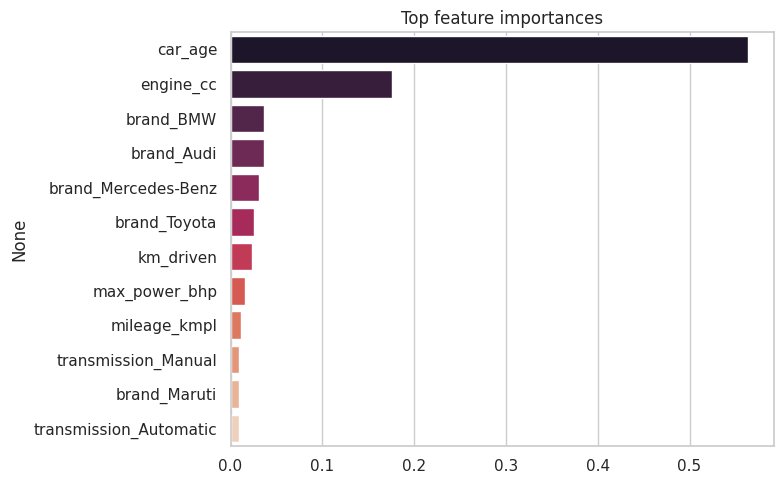

In [17]:
if best_name == "Random Forest":
    ohe = best_pipe.named_steps["pre"].named_transformers_["cat"]
    feat_names = num_feats + list(ohe.get_feature_names_out(cat_feats))
    imp = best_pipe.named_steps["model"].feature_importances_
    fi = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(12)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=fi.values, y=fi.index, palette="rocket")
    plt.title("Top feature importances"); plt.tight_layout(); plt.show()

### 3.3 Save the best model for deployment
The fitted pipeline (preprocessing + model) is saved with `joblib`. We also export
metadata (metrics, feature ranges, category lists) used by the web app.

In [18]:
joblib.dump(best_pipe, "car_price_model.joblib", compress=3)

meta = {
    "best_model": best_name,
    "metrics": {k: {m: float(results.loc[k, m]) for m in ["MAE","MSE","RMSE","R2"]} for k in results.index},
    "num_feats": num_feats,
    "cat_feats": cat_feats,
    "categories": {c: sorted(df[c].dropna().unique().tolist()) for c in cat_feats},
    "ranges": {c: [float(df[c].min()), float(df[c].max()), float(df[c].median())] for c in num_feats},
    "n_rows": int(len(df)),
}
with open("model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved: car_price_model.joblib  &  model_meta.json")
print("Best model:", best_name, "| Test R2 =", round(meta["metrics"][best_name]["R2"], 4))

Saved: car_price_model.joblib  &  model_meta.json
Best model: Random Forest | Test R2 = 0.907


## Summary
- Cleaned the data (missing values, duplicates, IQR outliers) and engineered numeric/brand/age features.
- Trained **Linear Regression** and **Random Forest**; compared with MAE/MSE/RMSE/R².
- **Random Forest** gave the best R² and was saved for **Step 4 (web deployment)**.
- The saved `car_price_model.joblib` is loaded by the Streamlit app, which takes user
  inputs, predicts the price, and shows the model's accuracy (R²).